<a href="https://colab.research.google.com/github/huseyinTozluyurt/Flyrank-Internship-MachineLearning/blob/main/notebooks/FlyRank_Binary_Classification_Needs_Refresh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FlyRank — Binary Classification: `needs_refresh`

## Business-oriented content refresh prediction

We transform content performance into:

- `1` → likely needs a refresh
- `0` → probably does not need a refresh

Starting hypothesis:

`trend_pct < -30%  → needs_refresh = 1`

The -30% threshold is treated as a **business hypothesis**, not as a proven optimal threshold. We inspect threshold sensitivity and model performance before using it operationally.

This notebook uses the CSV dataset only — no DuckDB.


In [1]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
else:
    # find the repo root from wherever this kernel started
    while not os.path.isdir("data/raw") and os.getcwd() != "/":
        os.chdir("..")

print("Working dir:", os.getcwd())
assert os.path.exists("data/raw/content_refresh_anonymized.csv"), "starter CSV not found — are you at the repo root?"
print("Starter data found. You're ready.")

Working dir: /content/flyrank-ml-internship-starter
Starter data found. You're ready.


In [2]:
# 1. Install and import libraries
!pip -q install xgboost scikit-learn pandas numpy matplotlib seaborn joblib

from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score,
    precision_score, recall_score, f1_score, classification_report,
    confusion_matrix, roc_curve, precision_recall_curve
)
from xgboost import XGBClassifier
import joblib

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
OUTPUT_DIR = Path("outputs_needs_refresh")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Libraries loaded.")


Libraries loaded.


In [3]:
# 2. Load the CSV dataset
CSV_PATH = "data/raw/content_refresh_anonymized.csv"
df = pd.read_csv(CSV_PATH)

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (30000, 44)


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


In [4]:
# 3. Inspect target-related columns
for col in ["trend_pct", "trend_direction", "is_declining_label"]:
    print(f"{col}: {'FOUND' if col in df.columns else 'NOT FOUND'}")

print("\nAll columns:")
print(list(df.columns))


trend_pct: FOUND
trend_direction: FOUND
is_declining_label: NOT FOUND

All columns:
['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct']


## 4. Define the business target

We prefer `trend_pct` because it lets us distinguish ordinary decline from a potentially meaningful deterioration.

For the initial experiment:

`needs_refresh = 1` when `trend_pct < -30%`.

The notebook also evaluates alternative thresholds so that the refresh rule can later be chosen scientifically and operationally.


In [5]:
# 5. Create needs_refresh
REFRESH_THRESHOLD = -30.0

if "trend_pct" not in df.columns:
    raise ValueError(
        "This notebook requires 'trend_pct' in the CSV to define needs_refresh."
    )

df["needs_refresh"] = (df["trend_pct"] < REFRESH_THRESHOLD).astype(int)

print(f"Threshold: trend_pct < {REFRESH_THRESHOLD}%")
display(
    df["needs_refresh"]
    .value_counts()
    .sort_index()
    .rename("count")
    .to_frame()
)

display(
    (df["needs_refresh"].value_counts(normalize=True)
     .sort_index().mul(100).rename("percentage").to_frame())
)


Threshold: trend_pct < -30.0%


,count
needs_refresh,
0,15894
1,14106


,percentage
needs_refresh,
0,52.98
1,47.02


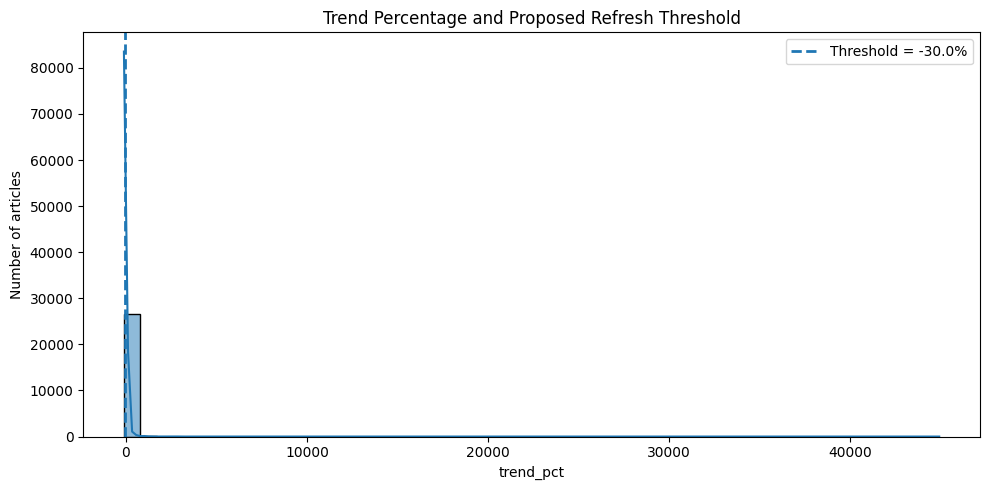

In [6]:
# 6. Visualize the proposed threshold
plt.figure(figsize=(10, 5))
sns.histplot(df["trend_pct"].dropna(), bins=50, kde=True)
plt.axvline(
    REFRESH_THRESHOLD, linestyle="--", linewidth=2,
    label=f"Threshold = {REFRESH_THRESHOLD}%"
)
plt.title("Trend Percentage and Proposed Refresh Threshold")
plt.xlabel("trend_pct")
plt.ylabel("Number of articles")
plt.legend()
plt.tight_layout()
plt.show()


In [7]:
# 7. Threshold sensitivity
candidate_thresholds = [-10, -20, -30, -40, -50, -60]

threshold_analysis = pd.DataFrame({
    "threshold_pct": candidate_thresholds,
    "refresh_count": [
        int((df["trend_pct"] < t).sum())
        for t in candidate_thresholds
    ]
})
threshold_analysis["refresh_rate_pct"] = (
    threshold_analysis["refresh_count"] / len(df) * 100
)

display(threshold_analysis)


,threshold_pct,refresh_count,refresh_rate_pct
0,-10,18248,60.826667
1,-20,16258,54.193333
2,-30,14106,47.020000
3,-40,11792,39.306667
4,-50,9365,31.216667
5,-60,7178,23.926667


# 8. Predictor design

We use content, search, traffic, engagement, and ranking variables.

We explicitly exclude:

- `trend_pct` — directly defines the target
- `trend_direction` — outcome information
- `is_declining_label` — previous outcome label
- `needs_refresh` — target itself

This prevents obvious target leakage.


In [8]:
# 9. Feature lists
NUMERIC_FEATURES = [
    "search_volume",
    "competition",
    "cpc",
    "word_count",
    "char_count",
    "impressions_prev_30d",
    "clicks_prev_30d",
    "sessions_prev_30d",
    "content_age_days",
    "days_since_last_update",
    "avg_position",
]

CATEGORICAL_FEATURES = [
    "competition_level",
    "content_type",
    "main_intent",
]

FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

missing = [c for c in FEATURES if c not in df.columns]
if missing:
    raise ValueError(f"Missing predictor columns: {missing}")

X = df[FEATURES].copy()
y = df["needs_refresh"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (30000, 14)
y shape: (30000,)


# 10. Train/test split

For this first CSV experiment, use a stratified 80/20 split.

This is appropriate as a baseline because it preserves the positive/negative class ratio.

For the final forecasting system, if a reliable time variable is available, we should replace this with temporal validation.


In [9]:
# 11. Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)


Train: (24000, 14)
Test : (6000, 14)


In [10]:
# 12. Leakage-safe preprocessing
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, NUMERIC_FEATURES),
    ("categorical", categorical_pipeline, CATEGORICAL_FEATURES),
])


# 13. Compare baseline classifiers

We compare:

- Logistic Regression
- Random Forest
- XGBoost

Because `needs_refresh=1` may be less common, **PR-AUC, recall, precision, and F1** are especially important alongside ROC-AUC.


In [11]:
# 14. Create models
positive_count = int(y_train.sum())
negative_count = int((y_train == 0).sum())
scale_pos_weight = negative_count / positive_count if positive_count else 1.0

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        class_weight="balanced",
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=6,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

print("scale_pos_weight:", scale_pos_weight)


scale_pos_weight: 1.1267168808152415


In [12]:
# 15. Train and evaluate
trained_pipelines = {}
rows = []

for name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    pipeline.fit(X_train, y_train)

    prob = pipeline.predict_proba(X_test)[:, 1]
    pred = (prob >= 0.50).astype(int)

    rows.append({
        "model": name,
        "ROC_AUC": roc_auc_score(y_test, prob),
        "PR_AUC": average_precision_score(y_test, prob),
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
    })
    trained_pipelines[name] = pipeline

results_df = (
    pd.DataFrame(rows)
    .sort_values("PR_AUC", ascending=False)
    .reset_index(drop=True)
)

display(results_df)


,model,ROC_AUC,PR_AUC,Accuracy,Precision,Recall,F1
0,XGBoost,0.812013,0.777397,0.727333,0.683040,0.783765,0.729944
1,Random Forest,0.801623,0.759897,0.721667,0.682525,0.762850,0.720455
2,Logistic Regression,0.637167,0.576186,0.606333,0.567839,0.680964,0.619278


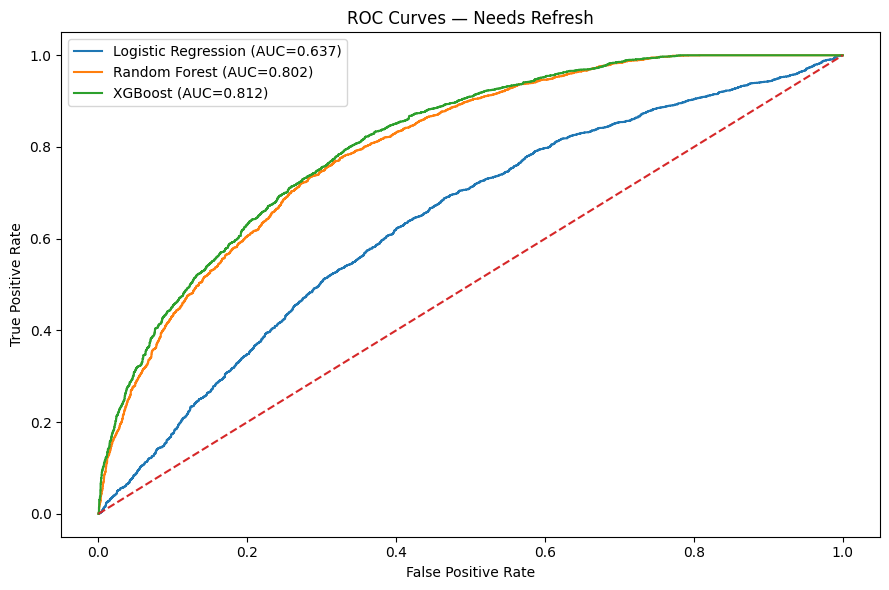

In [13]:
# 16. ROC curves
plt.figure(figsize=(9, 6))

for name, pipeline in trained_pipelines.items():
    prob = pipeline.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Needs Refresh")
plt.legend()
plt.tight_layout()
plt.show()


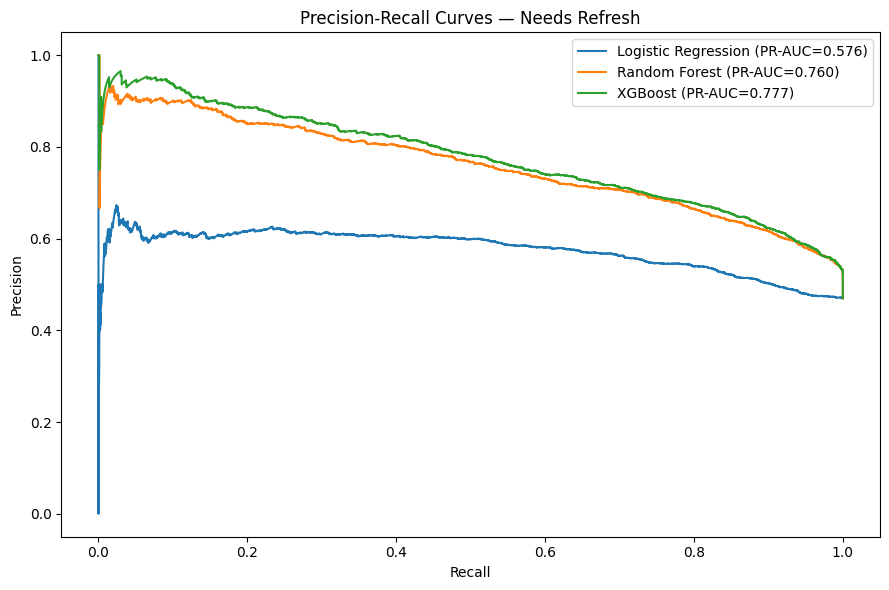

In [14]:
# 17. Precision-recall curves
plt.figure(figsize=(9, 6))

for name, pipeline in trained_pipelines.items():
    prob = pipeline.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    plt.plot(recall, precision, label=f"{name} (PR-AUC={ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves — Needs Refresh")
plt.legend()
plt.tight_layout()
plt.show()


# 18. Select an initial model

For this baseline experiment, select the model with the highest test PR-AUC.

This is only an initial selection rule. The final model should be validated with temporal/rolling validation if time information is available.


In [15]:
# 19. Select model
best_model_name = results_df.iloc[0]["model"]
best_pipeline = trained_pipelines[best_model_name]
best_probabilities = best_pipeline.predict_proba(X_test)[:, 1]

print("Initial best model:", best_model_name)
print("Test PR-AUC:", results_df.iloc[0]["PR_AUC"])


Initial best model: XGBoost
Test PR-AUC: 0.7773969278840971


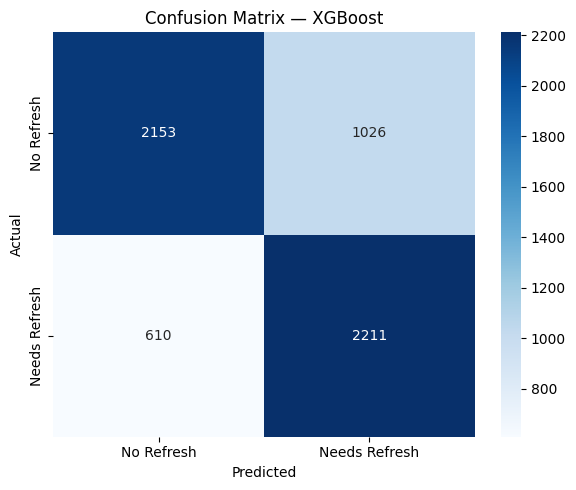

               precision    recall  f1-score   support

   No Refresh       0.78      0.68      0.72      3179
Needs Refresh       0.68      0.78      0.73      2821

     accuracy                           0.73      6000
    macro avg       0.73      0.73      0.73      6000
 weighted avg       0.73      0.73      0.73      6000



In [16]:
# 20. Default 0.50 confusion matrix
best_predictions = (best_probabilities >= 0.50).astype(int)
cm = confusion_matrix(y_test, best_predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["No Refresh", "Needs Refresh"],
    yticklabels=["No Refresh", "Needs Refresh"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix — {best_model_name}")
plt.tight_layout()
plt.show()

print(classification_report(
    y_test,
    best_predictions,
    target_names=["No Refresh", "Needs Refresh"],
    zero_division=0
))


# 21. Optimize the decision threshold

`0.50` is only a default probability cutoff.

A content-refresh system may prefer:

- lower threshold → catch more risky content
- higher threshold → reduce unnecessary refreshes

We therefore inspect the precision/recall/F1 trade-off.


In [17]:
# 22. Threshold analysis
thresholds = np.arange(0.10, 0.91, 0.05)
threshold_rows = []

for threshold in thresholds:
    pred = (best_probabilities >= threshold).astype(int)
    threshold_rows.append({
        "threshold": threshold,
        "flagged_count": int(pred.sum()),
        "flagged_pct": pred.mean() * 100,
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
    })

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df.round(3))


,threshold,flagged_count,flagged_pct,precision,recall,f1
0,0.10,5245,87.417,0.536,0.997,0.697
1,0.15,5089,84.817,0.549,0.990,0.706
2,0.20,4898,81.633,0.562,0.975,0.713
3,0.25,4692,78.200,0.578,0.961,0.722
4,0.30,4440,74.000,0.595,0.937,0.728
5,0.35,4151,69.183,0.618,0.910,0.736
6,0.40,3857,64.283,0.641,0.876,0.740
7,0.45,3570,59.500,0.661,0.837,0.739
8,0.50,3237,53.950,0.683,0.784,0.730
9,0.55,2886,48.100,0.704,0.721,0.712


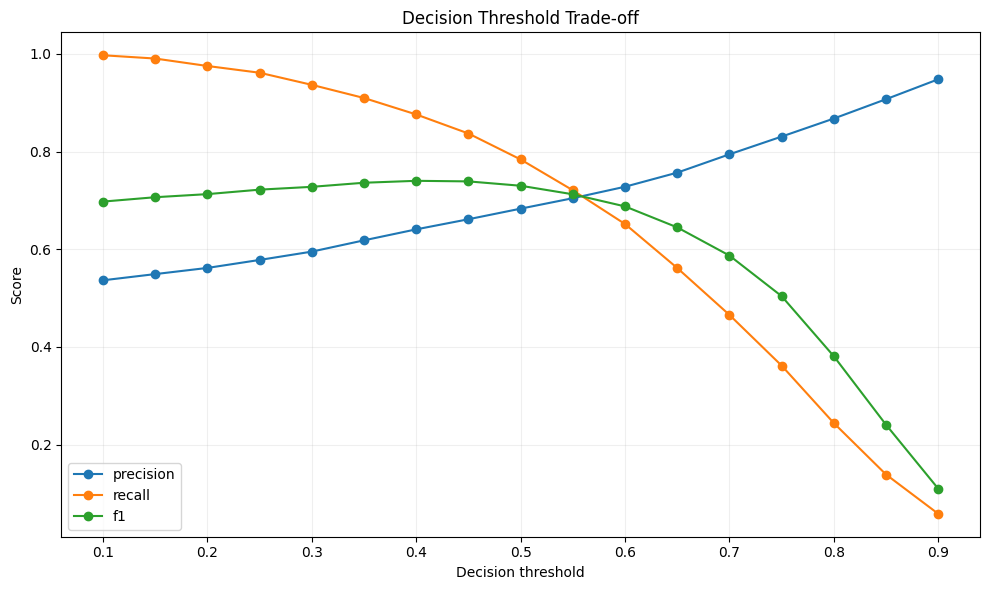

In [18]:
# 23. Threshold trade-off visualization
plt.figure(figsize=(10, 6))

for metric in ["precision", "recall", "f1"]:
    plt.plot(
        threshold_df["threshold"],
        threshold_df[metric],
        marker="o",
        label=metric
    )

plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.title("Decision Threshold Trade-off")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


# 24. Article-level refresh risk

The main operational output is a ranked list:

`article → P(needs_refresh)`

This allows a content team to prioritize the highest-risk articles instead of receiving only a binary prediction.


In [19]:
# 25. Build risk table
risk_scores = X_test.copy()
risk_scores["needs_refresh_probability"] = best_probabilities
risk_scores["actual_needs_refresh"] = y_test.values
risk_scores["predicted_needs_refresh"] = (
    best_probabilities >= 0.50
).astype(int)

risk_scores["risk_level"] = pd.cut(
    best_probabilities,
    bins=[-np.inf, 0.25, 0.50, 0.75, np.inf],
    labels=["LOW", "MEDIUM", "HIGH", "VERY HIGH"]
)

risk_scores = risk_scores.sort_values(
    "needs_refresh_probability",
    ascending=False
)

display(risk_scores.head(20))


,search_volume,competition,cpc,word_count,char_count,impressions_prev_30d,clicks_prev_30d,sessions_prev_30d,content_age_days,days_since_last_update,avg_position,competition_level,content_type,main_intent,needs_refresh_probability,actual_needs_refresh,predicted_needs_refresh,risk_level
1550,10.0,0.40,0.00,3097.0,21127.0,7,0,2,96,8,5.9,MEDIUM,keyword article,informational,0.984281,1,1,VERY HIGH
3734,10.0,0.00,0.00,3185.0,22269.0,13,0,1,96,8,4.5,LOW,keyword article,commercial,0.982985,1,1,VERY HIGH
18031,NaN,NaN,NaN,4302.0,30760.0,9,0,1,90,8,8.0,NaN,feedly article,NaN,0.981987,1,1,VERY HIGH
13498,0.0,0.00,0.00,2999.0,20696.0,5,0,1,90,8,5.7,LOW,keyword article,informational,0.981048,0,1,VERY HIGH
15939,10.0,0.79,0.00,3224.0,22100.0,7,0,1,96,8,7.8,HIGH,keyword article,commercial,0.977188,1,1,VERY HIGH
5715,0.0,0.00,0.00,2917.0,19997.0,164,0,1,90,8,6.5,LOW,keyword article,informational,0.976944,1,1,VERY HIGH
387,0.0,0.00,0.00,2907.0,19733.0,28,0,1,90,8,8.6,LOW,keyword article,informational,0.976476,1,1,VERY HIGH
20160,0.0,0.00,0.00,2886.0,19945.0,9,0,1,90,8,7.3,LOW,keyword article,informational,0.976413,1,1,VERY HIGH
14572,NaN,NaN,NaN,4428.0,30600.0,46,0,1,98,8,6.3,NaN,feedly article,NaN,0.976357,1,1,VERY HIGH
24834,10.0,0.61,6.04,2956.0,20279.0,93,0,2,96,8,8.2,MEDIUM,keyword article,informational,0.975312,1,1,VERY HIGH


In [20]:
# 26. Save outputs
risk_scores.to_csv(
    OUTPUT_DIR / "content_needs_refresh_risk_scores.csv"
)
results_df.to_csv(
    OUTPUT_DIR / "model_comparison.csv",
    index=False
)
threshold_df.to_csv(
    OUTPUT_DIR / "decision_threshold_analysis.csv",
    index=False
)
threshold_analysis.to_csv(
    OUTPUT_DIR / "refresh_threshold_sensitivity.csv",
    index=False
)

print("Outputs saved in:", OUTPUT_DIR)


Outputs saved in: outputs_needs_refresh


# 27. Initial model interpretation

If XGBoost is selected, inspect its native feature importance.

For detailed article-level explanations, connect this classifier to the **Opportunity 5 SHAP notebook**.


,feature,importance
5,numeric__impressions_prev_30d,0.150945
14,categorical__content_type_comparison article,0.086303
16,categorical__content_type_keyword article,0.072402
8,numeric__content_age_days,0.071249
6,numeric__clicks_prev_30d,0.071072
9,numeric__days_since_last_update,0.058704
10,numeric__avg_position,0.051411
7,numeric__sessions_prev_30d,0.043140
3,numeric__word_count,0.041049
11,categorical__competition_level_HIGH,0.040778


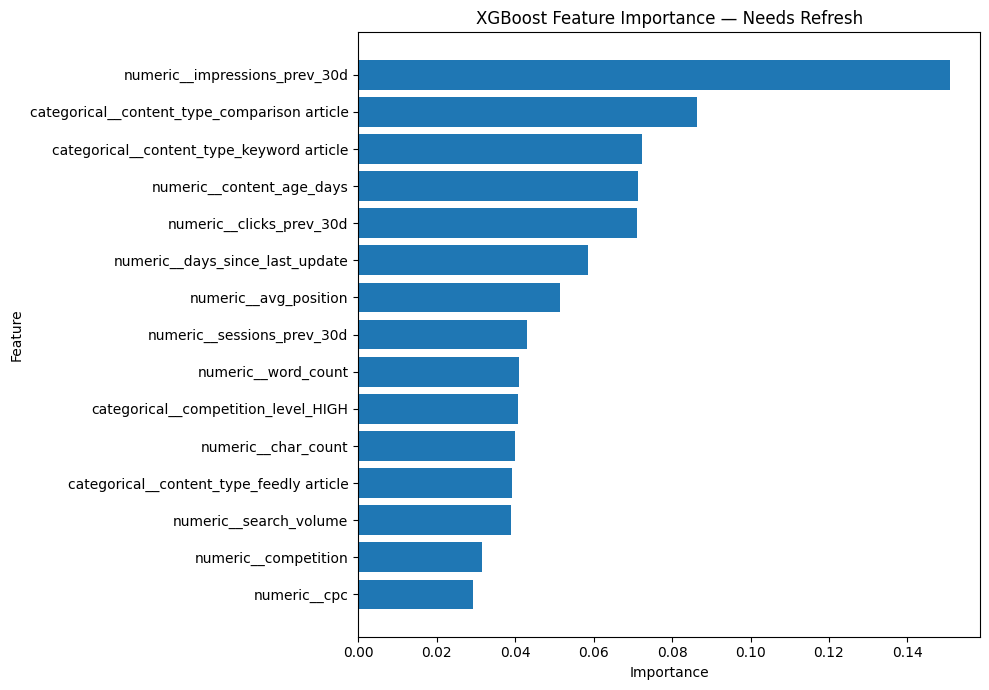

In [21]:
# 28. XGBoost feature importance
if best_model_name == "XGBoost":
    fitted_preprocessor = best_pipeline.named_steps["preprocessor"]
    fitted_model = best_pipeline.named_steps["model"]

    feature_names = fitted_preprocessor.get_feature_names_out()

    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": fitted_model.feature_importances_
    }).sort_values("importance", ascending=False)

    display(importance_df.head(20))

    plt.figure(figsize=(10, 7))
    plot_df = importance_df.head(15).sort_values("importance")
    plt.barh(plot_df["feature"], plot_df["importance"])
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title("XGBoost Feature Importance — Needs Refresh")
    plt.tight_layout()
    plt.show()

    importance_df.to_csv(
        OUTPUT_DIR / "xgboost_feature_importance.csv",
        index=False
    )
else:
    print("Best model is not XGBoost; skipping XGBoost-specific importance.")


# 29. Save the complete model pipeline

The saved object contains preprocessing + model + feature definitions + target threshold information.

This makes the classifier reusable for future content records with the same schema.


In [22]:
# 30. Save model artifacts
joblib.dump(
    {
        "pipeline": best_pipeline,
        "features": FEATURES,
        "numeric_features": NUMERIC_FEATURES,
        "categorical_features": CATEGORICAL_FEATURES,
        "refresh_target_threshold_pct": REFRESH_THRESHOLD,
        "decision_threshold": 0.50,
        "model_name": best_model_name,
    },
    OUTPUT_DIR / "needs_refresh_classifier.joblib"
)

print("Saved:", OUTPUT_DIR / "needs_refresh_classifier.joblib")


Saved: outputs_needs_refresh/needs_refresh_classifier.joblib


# 31. Example inference on future content

For new records:

```text
X
 ↓
trained pipeline
 ↓
P(needs_refresh)
 ↓
priority ranking
```

Example:

| Article | Probability | Decision |
|---|---:|---|
| A | 0.94 | Refresh |
| B | 0.82 | Refresh |
| C | 0.21 | Monitor |
| D | 0.05 | No refresh |

The probability is a prioritization signal, not a guarantee of future performance.


In [23]:
# 32. Example future inference template
#
# new_data = pd.read_csv("path/to/new_content.csv")
#
# artifacts = joblib.load(
#     OUTPUT_DIR / "needs_refresh_classifier.joblib"
# )
#
# probabilities = artifacts["pipeline"].predict_proba(
#     new_data[artifacts["features"]]
# )[:, 1]
#
# new_data["needs_refresh_probability"] = probabilities
# new_data["predicted_needs_refresh"] = (
#     probabilities >= artifacts["decision_threshold"]
# ).astype(int)
#
# display(
#     new_data.sort_values(
#         "needs_refresh_probability",
#         ascending=False
#     ).head(20)
# )


# 33. Methodological notes

### Target definition
The initial `trend_pct < -30%` rule is a business hypothesis. Validate it against historical outcomes and refresh capacity.

### Leakage
Do not use `trend_pct`, `trend_direction`, or future-period metrics as predictors.

### Validation
Random stratified splitting is a baseline. A final forecasting system should use temporal validation when dates are available.

### Probability
A probability such as `0.94` means the model strongly ranks the article as belonging to the refresh class. It does not mean that refreshing the article has a 94% chance of improving traffic.

### Explainability
Opportunity 5 provides SHAP-based answers to:

> **Why does the model think this article needs a refresh?**


# 34. Final FlyRank workflow

```text
Historical content data
        ↓
Define business target: needs_refresh
        ↓
Train binary classifier
        ↓
P(needs_refresh)
        ↓
Rank content by refresh risk
        ↓
Prioritize content operations
        ↓
SHAP explanation
        ↓
Refresh content
        ↓
Measure post-refresh outcomes
```

This converts content decline modeling into a practical **content-refresh decision system**.
